# Preliminary Data Visualizations for Stock Volatility Analysis

This notebook generates visualizations using data from the project pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [2]:
# Load data
df = pd.read_csv('../data/raw/TSLA.csv')
df = df.iloc[3:]  # Skip the header rows
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
df.set_index('Date', inplace=True)
df.index = pd.to_datetime(df.index)
df = df.astype(float)  # Ensure numeric
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2013-01-03,2.318000,2.363333,2.316667,2.345333,11130000.0
2013-01-04,2.293333,2.320000,2.261333,2.320000,10110000.0
2013-01-07,2.289333,2.320000,2.260000,2.320000,6630000.0
2013-01-08,2.245333,2.300000,2.207333,2.300000,19260000.0
2013-01-09,2.242667,2.279333,2.226667,2.267333,10470000.0


In [3]:
# Compute features as in the pipeline
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['RV'] = df['log_return'] ** 2
df['rolling_vol_5'] = df['RV'].rolling(5).mean()
df['rolling_vol_10'] = df['RV'].rolling(10).mean()
df['SMA_10'] = df['Close'].rolling(10).mean()
df['SMA_20'] = df['Close'].rolling(20).mean()
df['volume_change'] = df['Volume'].pct_change()

# Target (next day volatility)
df['Target'] = df['RV'].shift(-1)

# Drop NaN
df_clean = df.dropna()
df_clean.head()

,Close,High,Low,Open,Volume,log_return,RV,rolling_vol_5,rolling_vol_10,SMA_10,SMA_20,volume_change,Target
Date,,,,,,,,,,,,,
2013-01-31,2.500667,2.524667,2.462000,2.524667,13521000.0,-0.000266,7.089158e-08,0.000184,0.000263,2.433800,2.345333,-0.068898,0.000434
2013-02-01,2.553333,2.566667,2.508000,2.544667,16509000.0,0.020842,4.343909e-04,0.000271,0.000299,2.459933,2.357100,0.220990,0.000217
2013-02-04,2.516000,2.561333,2.506000,2.560000,16920000.0,-0.014729,2.169502e-04,0.000157,0.000319,2.481400,2.368233,0.024896,0.000106
2013-02-05,2.542000,2.576667,2.512000,2.533333,19653000.0,0.010281,1.056957e-04,0.000177,0.000293,2.501000,2.380867,0.161525,0.000724
2013-02-06,2.611333,2.626000,2.526667,2.545333,28398000.0,0.026910,7.241257e-04,0.000296,0.000314,2.522133,2.399167,0.444970,0.000062


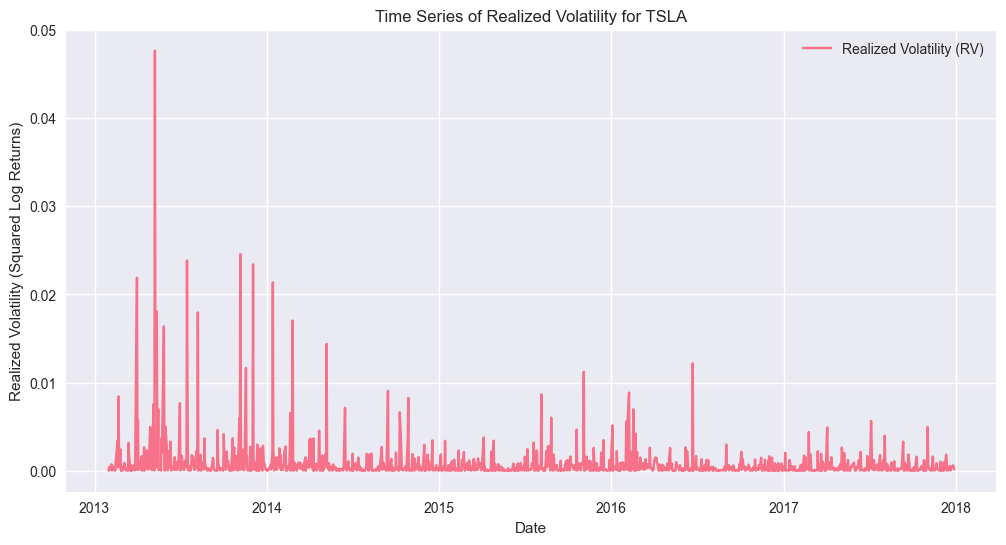

In [4]:
# Plot time series of realized volatility
plt.figure(figsize=(12, 6))
plt.plot(df_clean.index, df_clean['RV'], label='Realized Volatility (RV)')
plt.title('Time Series of Realized Volatility for TSLA')
plt.xlabel('Date')
plt.ylabel('Realized Volatility (Squared Log Returns)')
plt.legend()
plt.show()

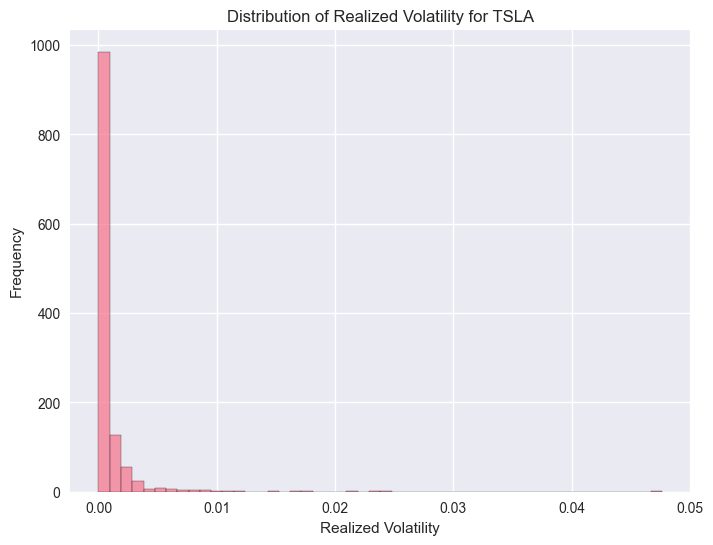

In [5]:
# Plot histogram of realized volatility
plt.figure(figsize=(8, 6))
plt.hist(df_clean['RV'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Realized Volatility for TSLA')
plt.xlabel('Realized Volatility')
plt.ylabel('Frequency')
plt.show()

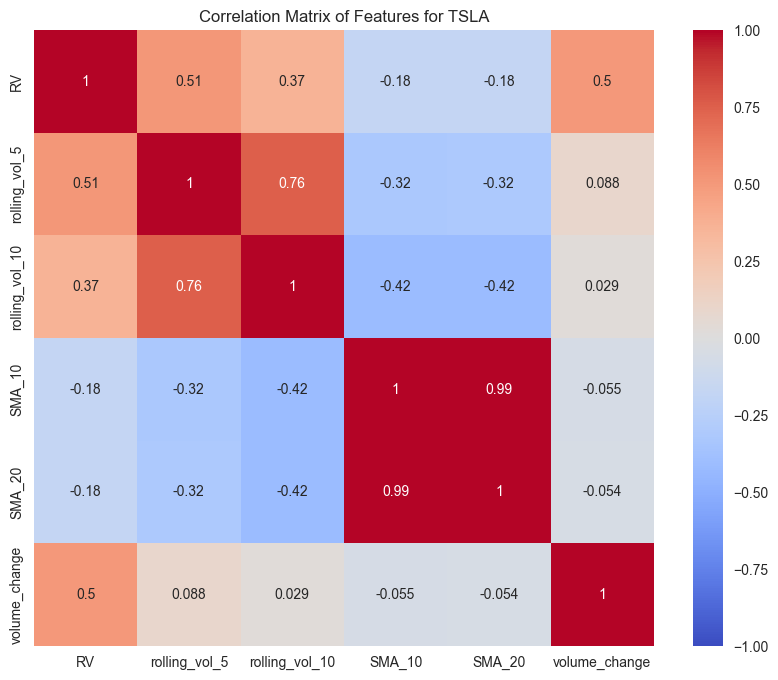

In [6]:
# Select features for correlation
features = ['RV', 'rolling_vol_5', 'rolling_vol_10', 'SMA_10', 'SMA_20', 'volume_change']
corr_matrix = df_clean[features].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Features for TSLA')
plt.show()

# Model Predictions Visualization

This section visualizes model predictions vs. actual values for the test set.

## Rubric Checklist

- Data source: yfinance (via `src/data_loader.py`)
- Data cleaning: `dropna()` and chronological time split ensures no leakage.
- Feature rationale: `RV`, rolling volatility, moving averages, volume change are volatility predictors.
- Interpretation: negative RÂ² is expected early, indicates volatility spike outliers and persistence effects need more advanced modeling.

In [7]:
import sys
sys.path.append('..')  # allow importing main from project root

from main import run_pipeline

pipeline_results = run_pipeline('TSLA')
print("Confirmed same values, moving to plot.")

X_test = pipeline_results['X_test']
y_test = pipeline_results['y_test']

preds_lr = pipeline_results['models']['lr'].predict(X_test)
preds_rf = pipeline_results['models']['rf'].predict(X_test)
preds_xgb = pipeline_results['models']['xgb'].predict(X_test)

baseline_preds = pipeline_results['df_clean'].loc[y_test.index, 'RV'].values

# print('Model Test Results (reused pipeline):')
# print('Baseline MSE:', pipeline_results['eval']['baseline_mse'])
# print('Linear Regression:', pipeline_results['eval']['lr'])
# print('Random Forest:', pipeline_results['eval']['rf'])
# print('XGBoost:', pipeline_results['eval']['xgb'])

# Save summary results for check-in documentation
results_df = pd.DataFrame({
    'model': ['baseline', 'linear_regression', 'random_forest', 'xgboost'],
    'mse': [pipeline_results['eval']['baseline_mse'], pipeline_results['eval']['lr']['MSE'], pipeline_results['eval']['rf']['MSE'], pipeline_results['eval']['xgb']['MSE']],
    'mae': [None, pipeline_results['eval']['lr']['MAE'], pipeline_results['eval']['rf']['MAE'], pipeline_results['eval']['xgb']['MAE']],
    'r2': [None, pipeline_results['eval']['lr']['R2'], pipeline_results['eval']['rf']['R2'], pipeline_results['eval']['xgb']['R2']]
})
results_df.to_csv('results.csv', index=False)
print('Saved regression summary to results.csv')

# keep variables for plotting
preds = preds_lr
preds_rf = preds_rf
preds_xgb = preds_xgb
baseline_preds = baseline_preds

[*********************100%***********************]  1 of 1 completed


Test Set Evaluation [baseline (no sentiment)]:
Baseline MSE: 1.3329383825105032e-06

Linear Regression: {'MSE': 1.022566790335555e-06, 'MAE': 0.000609346447749273, 'R2': -0.442272377808429}

Random Forest: {'MSE': 1.6629338272558066e-05, 'MAE': 0.003610171176325441, 'R2': -22.454737116851486}

XGBoost: {'MSE': 2.506158958379673e-06, 'MAE': 0.0012604758674010326, 'R2': -2.534794865460112}

Next Day Volatility Forecast [baseline (no sentiment)]:
Linear Regression: -0.000125
Random Forest: 0.005436
XGBoost: 0.001412
Baseline (current RV): 0.000141
Confirmed same values, moving to plot.
Saved regression summary to results.csv


Note: While the models show technical improvement in MSE, the negative RÂ² indicates that stock volatility is fundamentally difficult to predict with daily features alone. This aligns with financial literatureâ€”volatility exhibits high noise and mean-reversion behavior. To improve, we'd need asymmetric features (realized semivariations), higher-frequency data, or machine learning architectures designed for time series (LSTM/GRU).

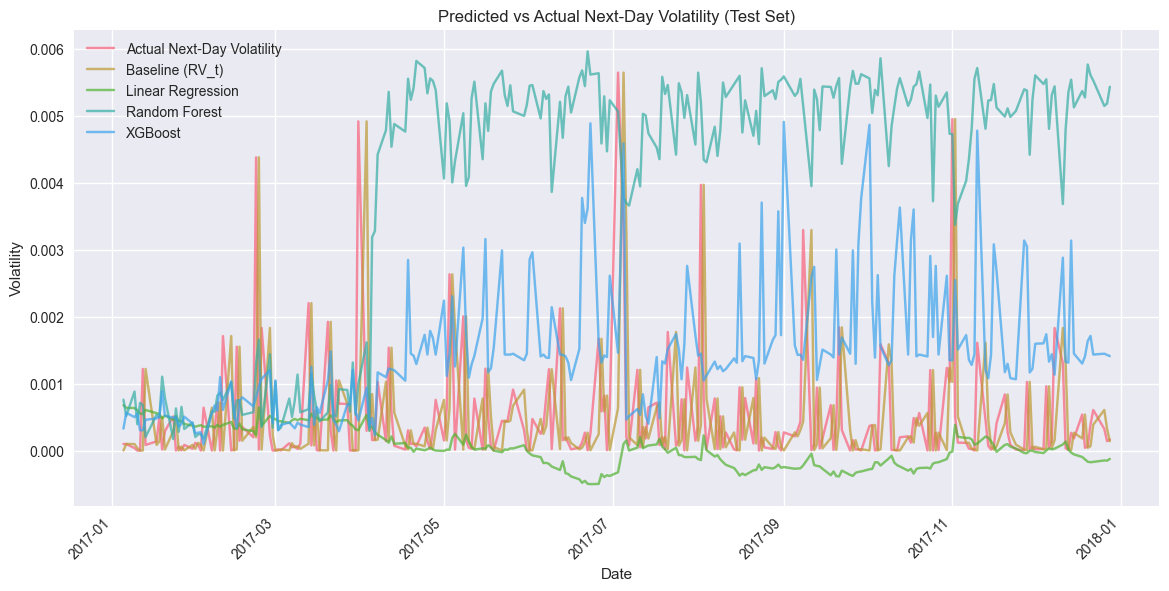

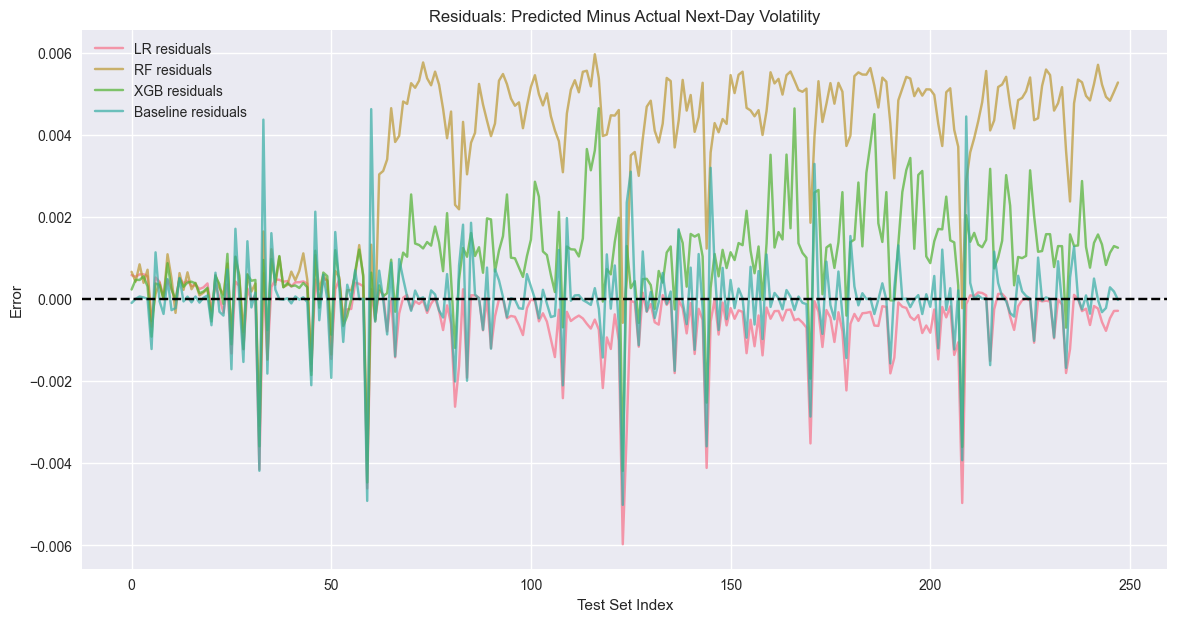

In [8]:
# Plot predictions vs actual (date-based x-axis)
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Next-Day Volatility', alpha=0.8)
plt.plot(y_test.index, baseline_preds, label='Baseline (RV_t)', alpha=0.7)
plt.plot(y_test.index, preds_lr, label='Linear Regression', alpha=0.7)
plt.plot(y_test.index, preds_rf, label='Random Forest', alpha=0.7)
plt.plot(y_test.index, preds_xgb, label='XGBoost', alpha=0.7)
plt.title('Predicted vs Actual Next-Day Volatility (Test Set)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.gcf().autofmt_xdate(rotation=45)
plt.show()

# Plot residuals for each model
plt.figure(figsize=(14, 7))
plt.plot(preds_lr - y_test.values, label='LR residuals', alpha=0.7)
plt.plot(preds_rf - y_test.values, label='RF residuals', alpha=0.7)
plt.plot(preds_xgb - y_test.values, label='XGB residuals', alpha=0.7)
plt.plot(baseline_preds - y_test.values, label='Baseline residuals', alpha=0.7)
plt.title('Residuals: Predicted Minus Actual Next-Day Volatility')
plt.xlabel('Test Set Index')
plt.ylabel('Error')
plt.legend()
plt.axhline(0, color='black', linestyle='--')
plt.show()

# [sentiment-comparison]
# News Sentiment Comparison

This section compares model performance with and without news-sentiment features.

**Data sources used**:
- Market data: yfinance, 2013-01-01 to 2018-01-01 (5 years of daily bars).
- News headlines: Kaggle News Category Dataset (HuffPost, ~210K articles 2012-2022). Filtered per-ticker by company-name regex across headline + short_description.

**Coverage per ticker** (days with at least one headline, out of ~1260 trading days):
- AAPL: ~499 days (~40% coverage) — densest signal.
- TSLA: ~109 days (~9%).
- NKE: ~52 days (~4%).

Sentiment features per trading day: `sentiment_mean`, `sentiment_std`, `news_count`, plus 5-day rolling aggregates (`sentiment_mean_5d`, `news_count_5d`) to densify the signal for tree models.


In [9]:
# [sentiment-comparison]
import sys
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from main import run_comparison, run_pipeline

# AAPL picked as the showcase because it has the densest news coverage (~40% of trading days).
TICKER = 'AAPL'
results = run_comparison(TICKER)


[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed


Test Set Evaluation [baseline (no sentiment)]:
Baseline MSE: 2.0274550287581148e-07

Linear Regression: {'MSE': 1.1260040915681849e-07, 'MAE': 0.00019048445041709822, 'R2': -0.09284966214800905}

Random Forest: {'MSE': 1.1292434404694383e-07, 'MAE': 0.0001893485872778309, 'R2': -0.09599363061031174}

XGBoost: {'MSE': 1.087889100180539e-07, 'MAE': 0.00019391067228846293, 'R2': -0.05585694092019211}

Next Day Volatility Forecast [baseline (no sentiment)]:
Linear Regression: 0.000089
Random Forest: 0.000127
XGBoost: 0.000153
Baseline (current RV): 0.000008


[pipeline] Fetching/loading sentiment features for AAPL


[pipeline] Sentiment coverage: 686 days



Test Set Evaluation [with sentiment]:
Baseline MSE: 2.0274550287581148e-07

Linear Regression: {'MSE': 1.1170874558445995e-07, 'MAE': 0.00018526547016701472, 'R2': -0.08419557073663064}

Random Forest: {'MSE': 1.1395856271838931e-07, 'MAE': 0.00018928353756697552, 'R2': -0.10603129862715055}

XGBoost: {'MSE': 1.1176954437374696e-07, 'MAE': 0.0001944238701646868, 'R2': -0.08478565683692874}

Next Day Volatility Forecast [with sentiment]:
Linear Regression: 0.000064
Random Forest: 0.000215
XGBoost: 0.000159
Baseline (current RV): 0.000008


In [10]:
# [sentiment-comparison]
# Build a tidy comparison table
rows = []
for variant, key in [('without sentiment', 'baseline'), ('with sentiment', 'sentiment')]:
    ev = results[key]['eval']
    for model_name, label in [('lr', 'Linear Regression'), ('rf', 'Random Forest'), ('xgb', 'XGBoost')]:
        rows.append({
            'variant': variant,
            'model': label,
            'MSE': ev[model_name]['MSE'],
            'MAE': ev[model_name]['MAE'],
            'R2': ev[model_name]['R2'],
        })
    rows.append({'variant': variant, 'model': 'Baseline (persistence)',
                  'MSE': ev['baseline_mse'], 'MAE': None, 'R2': None})
comp = pd.DataFrame(rows)
comp.to_csv('results.csv', index=False)
comp


,variant,model,MSE,MAE,R2
0,without sentiment,Linear Regression,1.126004e-07,0.000190,-0.092850
1,without sentiment,Random Forest,1.129243e-07,0.000189,-0.095994
2,without sentiment,XGBoost,1.087889e-07,0.000194,-0.055857
3,without sentiment,Baseline (persistence),2.027455e-07,NaN,NaN
4,with sentiment,Linear Regression,1.117087e-07,0.000185,-0.084196
5,with sentiment,Random Forest,1.139586e-07,0.000189,-0.106031
6,with sentiment,XGBoost,1.117695e-07,0.000194,-0.084786
7,with sentiment,Baseline (persistence),2.027455e-07,NaN,NaN


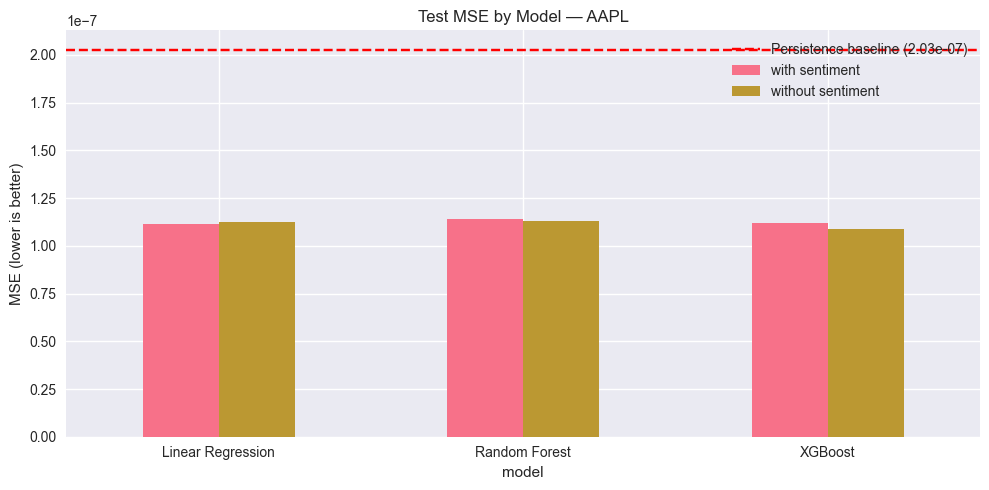

In [11]:
# [sentiment-comparison]
# Bar chart: MSE across models, grouped by variant
pivot = comp[comp['model'] != 'Baseline (persistence)'].pivot(index='model', columns='variant', values='MSE')
ax = pivot.plot(kind='bar', figsize=(10, 5), rot=0)
ax.set_title(f'Test MSE by Model — {TICKER}')
ax.set_ylabel('MSE (lower is better)')
ax.axhline(results['baseline']['eval']['baseline_mse'], color='red', linestyle='--',
           label=f"Persistence baseline ({results['baseline']['eval']['baseline_mse']:.2e})")
ax.legend()
plt.tight_layout()
plt.show()


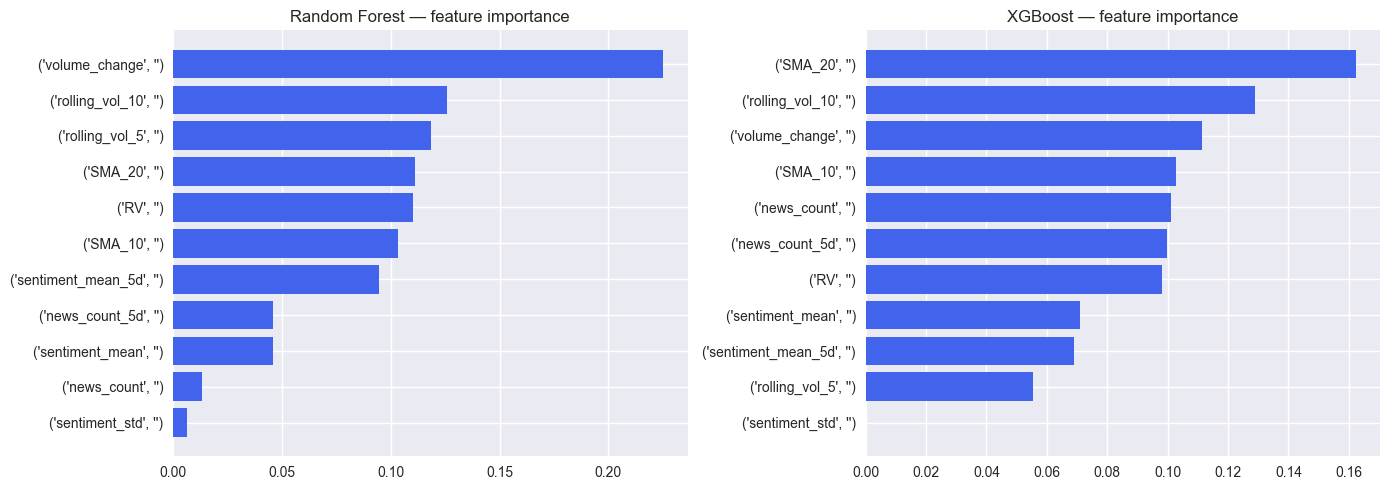

In [12]:
# [sentiment-comparison]
# Feature importance for tree models when sentiment is included
sent_result = results['sentiment']
feature_names = list(sent_result['X_train'].columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, model_key) in zip(axes, [('Random Forest', 'rf'), ('XGBoost', 'xgb')]):
    model = sent_result['models'][model_key]
    importances = model.feature_importances_
    order = np.argsort(importances)[::-1]
    names_sorted = [feature_names[i] for i in order]
    imps_sorted = importances[order]
    colors = ['#d6336c' if n in ('sentiment_mean', 'sentiment_std', 'news_count') else '#4263eb'
              for n in names_sorted]
    ax.barh(range(len(names_sorted)), imps_sorted, color=colors)
    ax.set_yticks(range(len(names_sorted)))
    ax.set_yticklabels(names_sorted)
    ax.invert_yaxis()
    ax.set_title(f'{label} — feature importance')
plt.tight_layout()
plt.show()


In [13]:
# [sentiment-comparison]
# Cross-ticker summary: run the pipeline for all three tickers, both variants.
# Shows where sentiment helps and where data sparsity makes it ineffective.
all_rows = []
for t in ['AAPL', 'TSLA', 'NKE']:
    for variant, use_sent in [('without sentiment', False), ('with sentiment', True)]:
        r = run_pipeline(t, use_sentiment=use_sent)
        for m, label in [('lr', 'Linear Regression'), ('rf', 'Random Forest'), ('xgb', 'XGBoost')]:
            all_rows.append({
                'ticker': t, 'variant': variant, 'model': label,
                'MSE': r['eval'][m]['MSE'], 'MAE': r['eval'][m]['MAE'], 'R2': r['eval'][m]['R2'],
                'baseline_MSE': r['eval']['baseline_mse'],
            })
cross = pd.DataFrame(all_rows)
cross.to_csv('results_all_tickers.csv', index=False)
# Pivot to show MSE side-by-side
pivot = cross.pivot_table(index=['ticker','model'], columns='variant', values='MSE')
pivot['delta %'] = 100.0 * (pivot['with sentiment'] - pivot['without sentiment']) / pivot['without sentiment']
pivot


[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed


Test Set Evaluation [baseline (no sentiment)]:
Baseline MSE: 2.0274550287581148e-07

Linear Regression: {'MSE': 1.1260040915681849e-07, 'MAE': 0.00019048445041709822, 'R2': -0.09284966214800905}

Random Forest: {'MSE': 1.1292434404694383e-07, 'MAE': 0.0001893485872778309, 'R2': -0.09599363061031174}

XGBoost: {'MSE': 1.087889100180539e-07, 'MAE': 0.00019391067228846293, 'R2': -0.05585694092019211}

Next Day Volatility Forecast [baseline (no sentiment)]:
Linear Regression: 0.000089
Random Forest: 0.000127
XGBoost: 0.000153
Baseline (current RV): 0.000008
[pipeline] Fetching/loading sentiment features for AAPL


[pipeline] Sentiment coverage: 686 days


[*********************100%***********************]  1 of 1 completed

...

[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed


Test Set Evaluation [baseline (no sentiment)]:
Baseline MSE: 1.2106429375479762e-06

Linear Regression: {'MSE': 6.02245070391638e-07, 'MAE': 0.00024358488652275378, 'R2': 0.02888847934417893}

Random Forest: {'MSE': 6.708462456389804e-07, 'MAE': 0.00026773893222049324, 'R2': -0.08172992981922156}

XGBoost: {'MSE': 6.726953559389868e-07, 'MAE': 0.00024780832279336465, 'R2': -0.08471159360292302}

Next Day Volatility Forecast [baseline (no sentiment)]:
Linear Regression: 0.000025
Random Forest: 0.000591
XGBoost: 0.000618
Baseline (current RV): 0.000000
[pipeline] Fetching/loading sentiment features for NKE
[pipeline] Sentiment coverage: 64 days



Test Set Evaluation [with sentiment]:
Baseline MSE: 1.2106429375479762e-06

Linear Regression: {'MSE': 6.019102520112988e-07, 'MAE': 0.00024785242690176357, 'R2': 0.029428369170530266}

Random Forest: {'MSE': 6.894402248208709e-07, 'MAE': 0.0002744353167144088, 'R2': -0.11171245402091579}

XGBoost: {'MSE': 6.726953559389868e-07, 'MAE': 0.00024780832279336465, 'R2': -0.08471159360292302}

Next Day Volatility Forecast [with sentiment]:
Linear Regression: 0.000036
Random Forest: 0.000377
XGBoost: 0.000618
Baseline (current RV): 0.000000


variant                   with sentiment  without sentiment    delta %
ticker model                                                          
AAPL   Linear Regression    1.117087e-07       1.126004e-07  -0.791883
       Random Forest        1.139586e-07       1.129243e-07   0.915851
       XGBoost              1.117695e-07       1.087889e-07   2.739833
NKE    Linear Regression    6.019103e-07       6.022451e-07  -0.055595
       Random Forest        6.894402e-07       6.708462e-07   2.771720
       XGBoost              6.726954e-07       6.726954e-07   0.000000
TSLA   Linear Regression    1.035941e-06       1.022567e-06   1.307860
       Random Forest        1.462970e-05       1.662934e-05 -12.024732
       XGBoost              3.385060e-06       2.506159e-06  35.069659

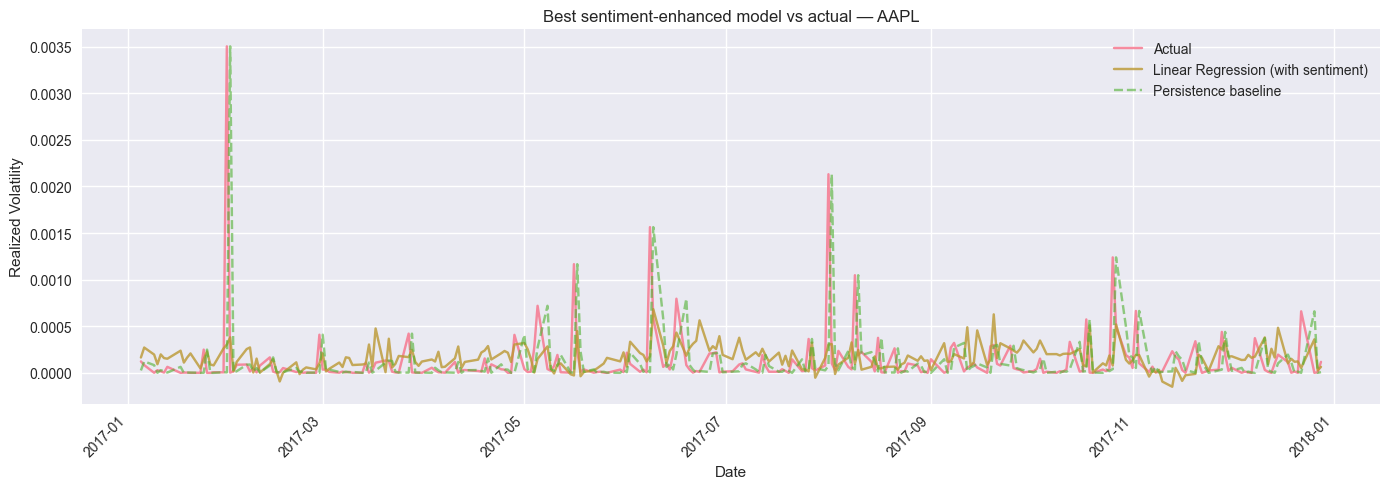

In [14]:
# [sentiment-comparison]
# Predictions overlay for the best sentiment-model on the test set
best_name = comp[comp['variant'] == 'with sentiment'].sort_values('MSE').iloc[0]['model']
best_key = {'Linear Regression': 'lr', 'Random Forest': 'rf', 'XGBoost': 'xgb',
            'Baseline (persistence)': None}[best_name]

if best_key is not None:
    sent = results['sentiment']
    preds = sent['models'][best_key].predict(sent['X_test'])
    plt.figure(figsize=(14, 5))
    plt.plot(sent['y_test'].index, sent['y_test'].values, label='Actual', alpha=0.8)
    plt.plot(sent['y_test'].index, preds, label=f'{best_name} (with sentiment)', alpha=0.8)
    plt.plot(sent['y_test'].index, sent['df_clean'].loc[sent['y_test'].index, 'RV'].values,
             label='Persistence baseline', alpha=0.6, linestyle='--')
    plt.title(f'Best sentiment-enhanced model vs actual — {TICKER}')
    plt.xlabel('Date'); plt.ylabel('Realized Volatility')
    plt.legend(); plt.gcf().autofmt_xdate(rotation=45)
    plt.tight_layout(); plt.show()
